In [1]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
import matplotlib as mpl
from helpers.simulation import *
from helpers.qtransform import *
from helpers.config import *

from scipy.stats import truncnorm
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from skimage.feature import peak_local_max

from astropy.cosmology import Planck18, z_at_value
from astropy import units as u

import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/gwaves_lisa_py311/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


## Training dataset filtering

In [2]:
with h5py.File(mixed_dataset_path, 'r+') as h5:
    t_qscan = h5['t_qscan'][:]
    f_qscan = h5['f_qscan'][:]

In [16]:
training_dict = {}
with h5py.File(training_dataset_path, 'r') as h5:
    for key in list(h5.keys()):
        training_dict[key] = h5[key][:]

In [26]:
def filter_by_snr(dataset_path, training_dict, label, threshold=8):
    with h5py.File(dataset_path, 'r') as h5:
        t_qscan = h5['t_qscan'][:]
        f_qscan = h5['f_qscan'][:]

    idx = np.where(np.all(training_dict['labels'] == label, axis=1))[0]
    images = training_dict['images'][idx]
    sim_idx = training_dict['sim_index'][idx]
    time_idx = training_dict['time_index'][idx]

    snrs = np.sqrt(images**2 - 1)
    t_axes = t_qscan[sim_idx, time_idx, :, :]
    f_axes = f_qscan[sim_idx, time_idx, :, :]

    good_idx = []
    for index in range(images.shape[0]):
        T_opt = []
        for j in range(snrs.shape[-1]):
            snr = snrs[index, :, :, j]
            t_axis = t_axes[index, :, j]
            f_axis = f_axes[index, :, j]
            _, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

            T_opt.append(T_grid[snr > threshold])
        
        T_opt = np.concatenate(T_opt)/3600
        if len(T_opt) < 2:
            if sum(label) == 0:
                good_idx.append(index)
            continue
        try:
            times = np.linspace(np.min(t_axes[index])/3600, np.max(t_axes[index])/3600, 250)
            pdf = gaussian_kde(T_opt)(times)
            peaks, _ = find_peaks(pdf, width=1, prominence=0.05)

            if len(peaks) >= sum(label):
                good_idx.append(index)
        except Exception as e:
            print(f"Sample {index}: {e}")

    good_idx = np.array(good_idx)
    return idx[good_idx]

In [29]:
good = filter_by_snr(glitch_dataset_path, training_dict, label=[0,1], threshold=8)

Sample 1992: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.
Sample 2017: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.


In [30]:
len(good)

3920

In [49]:
with h5py.File(training_dataset_path, 'r') as h5:
    sim_idx = h5['sim_index'][good_glitch]
    time_idx = h5['time_index'][good_glitch]

In [52]:
with h5py.File(glitch_dataset_path, 'r') as h5:
    inj_points = h5['inj_point'][:]

In [61]:
inj_point = inj_points[np.unique(sim_idx)].astype(str)
inj_point = inj_points[:].astype(str)

for point in ['tm_12', 'tm_23', 'tm_13',
              'tm_21', 'tm_32', 'tm_31']:
    count = len(np.where(inj_point == point)[0])
    print(f'{count} samples in {point}.')

157 samples in tm_12.
162 samples in tm_23.
177 samples in tm_13.
164 samples in tm_21.
187 samples in tm_32.
153 samples in tm_31.


In [41]:
transient_dict = {}
with h5py.File(training_dataset_path, 'r') as h5:
    for key in list(h5.keys()):
        transient_dict[key] = h5[key][:]

In [43]:
for key in transient_dict.keys():
    print(transient_dict[key].shape)

(17502, 256, 256, 2)
(17502, 2)
(17502,)
(17502,)


## 2D Search

In [12]:
mixed_dict = {}
with h5py.File(gw_dataset_path, 'r+') as h5:
    for key in list(h5.keys()):
        mixed_dict[key] = h5[key][:250]

In [37]:
i = 7
idx = np.argmin(np.abs(mixed_dict['tcen'][i]))
image = mixed_dict['QT'][i, idx, :, :, 1]
t_axis = mixed_dict['t_qscan'][i, idx, :, 1]
f_axis = np.log10(mixed_dict['f_qscan'][i, idx, :, 1])

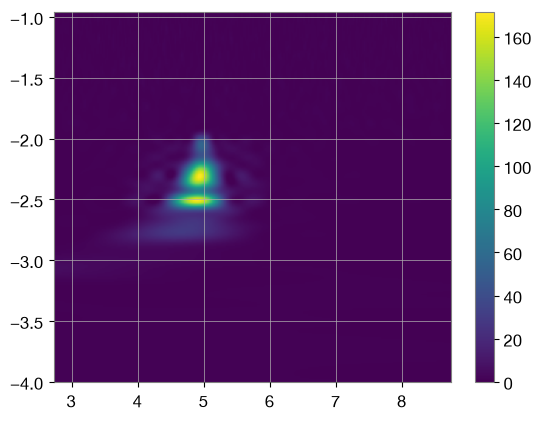

In [38]:
plt.imshow(image, extent=[t_axis[0]/3600, t_axis[-1]/3600, f_axis[0], f_axis[-1]],\
     aspect='auto', origin='lower')
#plt.title(f'Amp = {amp:.2g} m/s^2, Beta = {beta:.2g} secs,\n Inj_point: {inj_point}, t_inj: {tevent/3600} hrs', fontsize=12)
#plt.imshow(image, origin='lower')
plt.colorbar()

#plt.clim(0, 5)
#plt.ylabel('Log frequency')
#plt.xlabel('Time (hrs)')
plt.show()

In [39]:
threshold = 8
snr = np.sqrt(image**2 - 1)
F_grid, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

T_opt = T_grid[snr >= threshold]/3600
F_opt = F_grid[snr >= threshold]

times = np.linspace(np.min(T_opt), np.max(T_opt), 50)
log_freqs = np.linspace(np.min(F_opt), np.max(F_opt), 50)

In [40]:
samples = np.vstack((T_opt, F_opt))   # shape = (2, N)
kde = gaussian_kde(samples)
TT, FF = np.meshgrid(times, log_freqs, indexing="xy")
points = np.vstack((TT.ravel(), FF.ravel()))
pdf = kde(points).reshape(TT.shape)


In [45]:
from skimage.feature import peak_local_max

coords = peak_local_max(pdf, min_distance=10,      
    threshold_rel=0.5,exclude_border=False)

In [46]:
times[coords[:, 1]], log_freqs[coords[:, 0]]

(array([4.836735], dtype=float32), array([-2.549049], dtype=float32))

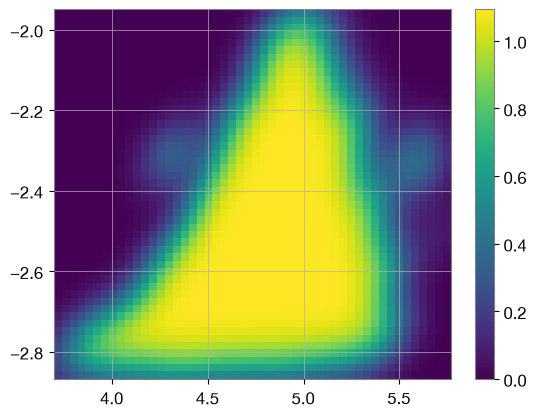

In [26]:
plt.imshow(pdf,extent=[times[0], times[-1], log_freqs[0], log_freqs[-1]], aspect='auto', origin='lower')
plt.colorbar()
#plt.scatter(coords[:, 1], coords[:, 0], s=15, marker='x', color='red')
plt.show()

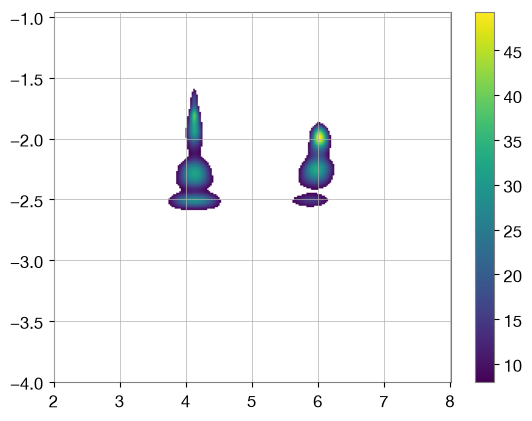

In [59]:
snr2 = snr.copy()
snr2[snr2 < 8] = np.nan
plt.imshow(snr2, extent=[t_axis[0]/3600, t_axis[-1]/3600, f_axis[0], f_axis[-1]],\
     aspect='auto', origin='lower')
#plt.title(f'Amp = {amp:.2g} m/s^2, Beta = {beta:.2g} secs,\n Inj_point: {inj_point}, t_inj: {tevent/3600} hrs', fontsize=12)
#plt.imshow(image, origin='lower')
plt.colorbar()

#plt.clim(0, 5)
#plt.ylabel('Log frequency')
#plt.xlabel('Time (hrs)')
plt.show()

In [5]:
training_dict = {}
with h5py.File(training_dataset_path, 'r') as h5:
    for key in list(h5.keys()):
        training_dict[key] = h5[key][:]

In [334]:
idx = np.where(np.all(training_dict['labels'] == [0,1], axis=1))[0]
len(idx)

5000

In [376]:
def filter_by_snr2(dataset_path, training_dict, label, threshold=8):
    with h5py.File(dataset_path, 'r') as h5:
        t_qscan = h5['t_qscan'][:]
        f_qscan = h5['f_qscan'][:]

    idx = np.where(np.all(training_dict['labels'] == label, axis=1))[0]
    images = training_dict['images'][idx]
    sim_idx = training_dict['sim_index'][idx]
    time_idx = training_dict['time_index'][idx]

    snrs = np.sqrt(images**2 - 1)
    t_axes = t_qscan[sim_idx, time_idx, :, :]
    f_axes = f_qscan[sim_idx, time_idx, :, :]

    good_idx, counts = [], []
    for index in range(images.shape[0]):
        F_opt, T_opt = [], []
        for j in range(snrs.shape[-1]):
            snr = snrs[index, :, :, j]
            t_axis = t_axes[index, :, j]/3600
            f_axis = np.log10(f_axes[index, :, j])
            F_grid, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

            T_opt.append(T_grid[snr >= threshold])
            F_opt.append(F_grid[snr >= threshold])
        
        T_opt = np.concatenate(T_opt)
        F_opt = np.concatenate(F_opt)
        if len(T_opt) < 2:
            if sum(label) == 0:
                good_idx.append(index)
            continue
        try:
            samples = np.vstack((T_opt, F_opt))
            kde = gaussian_kde(samples)

            times = np.linspace(np.min(T_opt), np.max(T_opt), 50)
            log_freqs = np.linspace(np.min(F_opt), np.max(F_opt), 50)

            TT, FF = np.meshgrid(times, log_freqs, indexing="xy")
            points = np.vstack((TT.ravel(), FF.ravel()))
            pdf = kde(points).reshape(TT.shape)

            coords = peak_local_max(pdf, min_distance=1,      
                    threshold_rel=0.2, exclude_border=False)
            counts.append(len(coords))
            if len(coords) >= sum(label):
                good_idx.append(index)
        except Exception as e:
            print(f"Sample {index}: {e}")
            counts.append(0)
        #if index%10 == 0:
         #   print(f'Image {index} out of {images.shape[0]} done')

    good_idx = np.array(good_idx)
    return idx[good_idx], np.array(counts)

In [3]:
def filter_by_snr2(training_dict, label, threshold=8):
    idx = np.where(np.all(training_dict['labels'] == label, axis=1))[0]
    images = training_dict['images'][idx]

    snrs = np.sqrt(images**2 - 1)

    good_idx, counts = [], []
    for index in range(images.shape[0]):
        counts = []
        for j in range(snrs.shape[-1]):
            snr = snrs[index, :, :, j]
            image = images[index, :, :, j]
            image[(snr <= threshold) | np.isnan(snr)] = 0

            coords = peak_local_max(image, min_distance=10,      
                threshold_rel=0.5,exclude_border=False)
            
            counts.append(len(coords))
        
        if max(counts) >= sum(label):
            good_idx.append(index)
        #if index%10 == 0:
         #   print(f'Image {index} out of {images.shape[0]} done')

    good_idx = np.array(good_idx)
    return idx[good_idx]

In [377]:
good = filter_by_snr2(mixed_dataset_path, training_dict, label=[1,1], threshold=8)

In [406]:
good = filter_by_snr2(training_dict, label=[1,1], threshold=5)

In [407]:
len(good)

6418

In [378]:
good

(array([11250, 11251, 11252, ..., 18683, 18684, 18685],
       shape=(6226,)),
 array([2, 2, 2, ..., 4, 4, 3], shape=(7404,)))

In [383]:
good[1]

array([2, 2, 2, ..., 4, 4, 3], shape=(7404,))

In [379]:
good2 = filter_by_snr(mixed_dataset_path, training_dict, label=[1,1])

In [402]:
len(good2)

4229

In [384]:
np.setdiff1d(good2, good[0])

array([11785, 11786, 11787, 12462, 12463, 12465, 12615, 12616,
       12617, 12848, 13379, 13504, 13505, 13613, 13666, 13667,
       13794, 13857, 13900, 13901, 14174, 14642, 14690, 14782,
       14784, 14863, 15184, 15662, 15730, 15943, 15944, 16038,
       16039, 16040, 16041, 16042, 16095, 16178, 16179, 16441,
       16444, 16453, 16921, 17360, 17367, 18383, 18384, 18484])

In [310]:
np.setdiff1d(good, good2)

array([], dtype=int64)

In [247]:
len(good2), len(good)

(4229, 4181)

In [7]:
with h5py.File(mixed_dataset_path, 'r+') as h5:
    t_qscan = h5['t_qscan'][:]
    f_qscan = h5['f_qscan'][:]

In [8]:
idx = [11785]
images = training_dict['images'][idx]
sim_idx = training_dict['sim_index'][idx]
time_idx = training_dict['time_index'][idx]

snrs = np.sqrt(images**2 - 1)
t_axes = t_qscan[sim_idx, time_idx, :, :]
f_axes = f_qscan[sim_idx, time_idx, :, :]

threshold = 8
good_idx, counts = [], []
for index in range(images.shape[0]):
    start = time.time()
    F_opt, T_opt = [], []
    for j in range(snrs.shape[-1]):
        snr = snrs[index, :, :, j]
        t_axis = t_axes[index, :, j]/3600
        f_axis = np.log10(f_axes[index, :, j])
        F_grid, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

        T_opt.append(T_grid[snr >= threshold])
        F_opt.append(F_grid[snr >= threshold])
    
    T_opt = np.concatenate(T_opt)
    F_opt = np.concatenate(F_opt)
    if len(T_opt) < 2:
        if sum(label) == 0:
            good_idx.append(index)
        continue
    try:
        samples = np.vstack((T_opt, F_opt))
        kde = gaussian_kde(samples, bw_method=0.2)

        times = np.linspace(np.min(T_opt), np.max(T_opt), 30)
        log_freqs = np.linspace(np.min(F_opt), np.max(F_opt), 30)

        TT, FF = np.meshgrid(times, log_freqs, indexing="xy")
        points = np.vstack((TT.ravel(), FF.ravel()))
        pdf = kde(points).reshape(TT.shape)

        coords = peak_local_max(pdf, min_distance=2,      
                threshold_rel=0.2,exclude_border=False)
        #counts.append(len(coords))
        if len(coords) >= 2:
            good_idx.append(index)
            counts.append(len(coords))
    except Exception as e:
        print(f"Sample {index}: {e}")
        counts.append(0)
    end = time.time()
    print((end-start)*7500/60)
    #if index%10 == 0:
        #   print(f'Image {index} out of {images.shape[0]} done')


12.077391147613525


In [9]:
coords

array([[13, 17]])

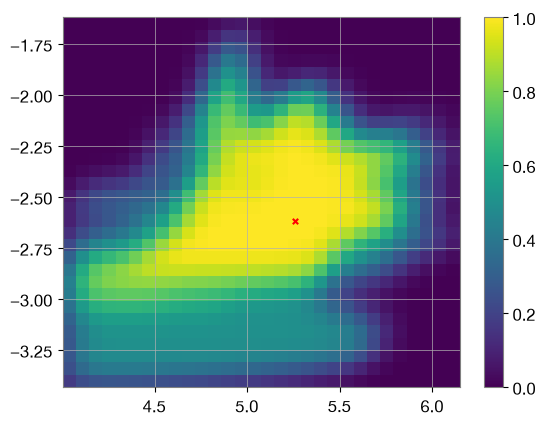

In [10]:
plt.imshow(pdf,extent=[times[0], times[-1], log_freqs[0], log_freqs[-1]], aspect='auto', origin='lower')

plt.scatter(times[coords[:,1]], log_freqs[coords[:,0]], s=15, color='red', marker='x')
plt.colorbar()

[[145  54]]


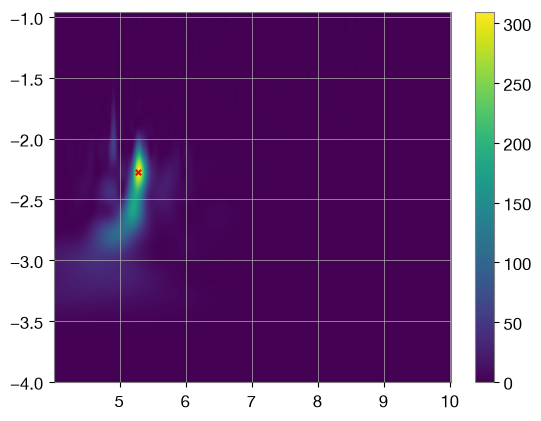

In [11]:
image = images[0,:,:,0]
snr = np.sqrt(image**2 - 1)
#snr[snr < 16] = np.nan

image2 = image.copy()
image2[(snr < 8) | np.isnan(snr)] = 0
coords = peak_local_max(image2, min_distance=10,      
                threshold_rel=0.5,exclude_border=False)
print(coords)

plt.imshow(image, extent=[t_axis[0], t_axis[-1], f_axis[0], f_axis[-1]],\
     aspect='auto', origin='lower')
#plt.clim(0, 10)
plt.colorbar()
plt.scatter(t_axis[coords[:,1]], f_axis[coords[:,0]], s=15, color='red', marker='x')

In [ ]:
idx = np.where(np.all(training_dict['labels'] == label, axis=1))[0]